# 03 — Cluster dinamico (anno per anno) + analisi sport e popolazione

Costruisce il cluster socioeconomico **dinamico**: a ogni combinazione paese-anno viene assegnato il cluster calcolato sugli indicatori di quello specifico anno (non il cluster più recente/attuale del paese). Con questo cluster vengono poi rifatte tutte le analisi legate agli sport (in entrambe le prospettive: quali sport dominano in ogni cluster / chi domina ogni sport) e la normalizzazione per popolazione.

**File necessari:** `olympics_dataset.csv` (Kaggle, medaglie), `olympics_with_clusters.csv` (da `02_Clustering_Metodologia.ipynb`)
**File prodotti:**
- `olympics_sport_cluster.csv` — medaglie con cluster dinamico assegnato
- `mobility_dynamic.csv` — tabella paese-anno → cluster dinamico (serve a `04_Cluster_Statico.ipynb` e `06_Grafici_Altair.ipynb`)
- `cluster_pc_summary_dynamic.csv` — medaglie pro capite medie per cluster (serve al confronto in `04_Cluster_Statico.ipynb`)

### Nota sulla ricostruzione del modello
Il cluster dinamico riapplica, anno per anno, lo **stesso modello multivariato** (`imp_multi`, `scaler_multi`, `km4`, `rank_map`) addestrato in `02_Clustering_Metodologia.ipynb`. Per restare indipendente da quel notebook, qui lo ri-addestriamo con lo stesso identico codice, stessi dati (`latest`, derivato da `olympics_with_clusters.csv`) e stesso `random_state=42`: il risultato è identico, byte per byte.

In [1]:
# %% [1] IMPORT
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

## Ricostruzione del modello multivariato di riferimento

In [2]:
# %% [0] RICOSTRUZIONE DEL MODELLO MULTIVARIATO DI RIFERIMENTO
# -----------------------------------------------------------------------------
# Stesso identico codice di 02_Clustering_Metodologia.ipynb (celle [1]-[R2]):
# stessi dati derivati da 'olympics_with_clusters.csv', stesso random_state=42
# -> imp_multi, scaler_multi, km4 e rank_map risultano identici.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

CLUSTER_ORDER = ['Ricchi avanzati', 'Reddito medio-alto',
                 'Reddito basso-medio', 'Poveri estremi']
CLUSTER_COLORS = {
    'Ricchi avanzati':     '#185FA5',
    'Reddito medio-alto':  '#3B6D11',
    'Reddito basso-medio': '#BA7517',
    'Poveri estremi':      '#A32D2D',
}
MULTI_VARS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
              'infant_mortality', 'primary_school_enrollment']

clustered_ref = pd.read_csv('olympics_with_clusters.csv')
latest = (clustered_ref[clustered_ref[MULTI_VARS].notna().sum(axis=1) >= 3]
          .sort_values('year').groupby('noc').last().reset_index())
latest_multi = latest.dropna(subset=['cluster_wb']).copy()

imp_multi = SimpleImputer(strategy='median')
X_multi_imp = imp_multi.fit_transform(latest[MULTI_VARS])
scaler_multi = StandardScaler()
X_multi_sc = scaler_multi.fit_transform(X_multi_imp)

X_compare_imp = imp_multi.transform(latest_multi[MULTI_VARS])
X_compare_sc = scaler_multi.transform(X_compare_imp)
km4 = KMeans(n_clusters=4, n_init=10, random_state=42)
latest_multi['cluster_multivariato'] = km4.fit_predict(X_compare_sc)

centroid_gdp = (latest_multi.groupby('cluster_multivariato')['gdp_per_capita']
                .mean().sort_values(ascending=False))
rank_map = {old: CLUSTER_ORDER[i] for i, old in enumerate(centroid_gdp.index)}

print("Modello multivariato di riferimento ricostruito.")
print(f"Paesi usati per il fit: {len(latest)} (di cui {len(latest_multi)} con cluster_wb per il fit di km4)")

Modello multivariato di riferimento ricostruito.
Paesi usati per il fit: 206 (di cui 206 con cluster_wb per il fit di km4)


In [3]:
# %% [2] CARICAMENTO
# -----------------------------------------------------------------------------
kaggle = pd.read_csv('olympics_dataset.csv')
clustered = pd.read_csv('olympics_with_clusters.csv')

print(f"Kaggle:    {kaggle.shape[0]:,} righe × {kaggle.shape[1]} colonne")
print(f"Clustered: {clustered.shape[0]:,} righe × {clustered.shape[1]} colonne")
print()
print("Colonne Kaggle:", kaggle.columns.tolist())
print("Colonne Clustered:", clustered.columns.tolist())

Kaggle:    252,565 righe × 11 colonne
Clustered: 3,368 righe × 26 colonne

Colonne Kaggle: ['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
Colonne Clustered: ['edition', 'year', 'country', 'noc', 'gold', 'silver', 'bronze', 'total_medals', 'host_country_code', 'host_city', 'gdp_per_capita', 'life_expectancy', 'urbanization_pct', 'population', 'pop_density', 'primary_school_enrollment', 'infant_mortality', 'gdp_total', 'medals_per_million', 'gold_per_million', 'medals_per_gdp_bn', 'won_medal', 'hdi', 'cluster_wb', 'cluster_label', 'cluster']


## Allineamento dei codici paese e costruzione del cluster dinamico

In [4]:
# %% [3] MAPPING NOC — ALLINEAMENTO DEI CODICI PAESE
# -----------------------------------------------------------------------------
# I due dataset usano sistemi di codici diversi in alcuni casi:
#   - Kaggle usa codici IOC (es. NED, SUI, DEN)
#   - Clustered usa in parte codici ISO3 (es. NLD, CHE, DNK)
# Serve anche gestire i paesi storici del Kaggle (es. URS = URSS).
#
# Strategia:
#   1. Mappiamo i codici ISO3 del clustered -> IOC per allinearli al Kaggle
#   2. Per URS (URSS, 2063 medaglie): la assegnamo al cluster di RUS (Russia)
#      perché è la principale entità successore e il dataset socioeconomico
#      usa RUS per il periodo sovietico. Nota questo nella tua tesi/report.

# Mapping ISO3 -> IOC (solo i casi che differiscono)
ISO3_TO_IOC = {
    'ABW': 'ARU',  # Aruba
    'AGO': 'ANG',  # Angola
    'ARE': 'UAE',  # Emirati Arabi
    'ASM': 'ASA',  # Samoa Americane
    'ATG': 'ANT',  # Antigua e Barbuda
    'BFA': 'BUR',  # Burkina Faso
    'BGD': 'BAN',  # Bangladesh
    'BGR': 'BUL',  # Bulgaria
    'BHR': 'BRN',  # Bahrain
    'BHS': 'BAH',  # Bahamas
    'BLZ': 'BIZ',  # Belize
    'BMU': 'BER',  # Bermuda
    'BRB': 'BAR',  # Barbados
    'BTN': 'BHU',  # Bhutan
    'BWA': 'BOT',  # Botswana
    'CHE': 'SUI',  # Svizzera
    'CHL': 'CHI',  # Cile
    'COG': 'CGO',  # Congo
    'CRI': 'CRC',  # Costa Rica
    'CYM': 'CAY',  # Isole Cayman
    'DNK': 'DEN',  # Danimarca
    'DZA': 'ALG',  # Algeria
    'FJI': 'FIJ',  # Figi
    'GIN': 'GUI',  # Guinea
    'GMB': 'GAM',  # Gambia
    'GNB': 'GBS',  # Guinea-Bissau
    'GNQ': 'GEQ',  # Guinea Equatoriale
    'GRC': 'GRE',  # Grecia
    'GRD': 'GRN',  # Grenada
    'GTM': 'GUA',  # Guatemala
    'HND': 'HON',  # Honduras
    'HRV': 'CRO',  # Croazia
    'HTI': 'HAI',  # Haiti
    'IDN': 'INA',  # Indonesia
    'IRN': 'IRI',  # Iran
    'KHM': 'CAM',  # Cambogia
    'KNA': 'SKN',  # Saint Kitts e Nevis
    'KWT': 'KUW',  # Kuwait
    'LBY': 'LBA',  # Libia
    'LKA': 'SRI',  # Sri Lanka
    'LSO': 'LES',  # Lesotho
    'LVA': 'LAT',  # Lettonia
    'MAC': 'MAC',  # Macao (uguale)
    'MCO': 'MON',  # Monaco
    'MDG': 'MAD',  # Madagascar
    'MMR': 'MYA',  # Myanmar
    'MNG': 'MGL',  # Mongolia
    'MRT': 'MTN',  # Mauritania
    'MUS': 'MRI',  # Mauritius
    'MWI': 'MAW',  # Malawi
    'MYS': 'MAS',  # Malaysia
    'NER': 'NIG',  # Niger
    'NGA': 'NGR',  # Nigeria
    'NIC': 'NCA',  # Nicaragua
    'NLD': 'NED',  # Olanda
    'NPL': 'NEP',  # Nepal
    'OMN': 'OMA',  # Oman
    'PHL': 'PHI',  # Filippine
    'PRI': 'PUR',  # Porto Rico
    'PRT': 'POR',  # Portogallo
    'PRY': 'PAR',  # Paraguay
    'PSE': 'PLE',  # Palestina
    'SAU': 'KSA',  # Arabia Saudita
    'SDN': 'SUD',  # Sudan
    'SLV': 'ESA',  # El Salvador
    'SVN': 'SLO',  # Slovenia
    'SYC': 'SEY',  # Seychelles
    'TCD': 'CHA',  # Ciad
    'TZA': 'TAN',  # Tanzania
    'VCT': 'VIN',  # Saint Vincent e Grenadine
    'VUT': 'VAN',  # Vanuatu
    'WSM': 'SAM',  # Samoa
    'ZAF': 'RSA',  # Sudafrica
}

In [5]:
# Applichiamo il mapping al dataset clustered
clustered['noc_ioc'] = clustered['noc'].replace(ISO3_TO_IOC)

In [6]:
# %% [3bis] CLUSTER DINAMICO ANNO PER ANNO — VERSIONE MULTIVARIATA
# -----------------------------------------------------------------------------
# D'ora in avanti TUTTE le analisi sport (heatmap, indice di specializzazione,
# chi-quadro, "chi domina ogni sport", sport "democratici", stacked bar,
# analisi pro capite) usano il cluster DINAMICO: il cluster socioeconomico
# REALE del paese nell'anno in cui ha vinto la medaglia — non il suo cluster
# più recente/attuale. Riapplichiamo lo stesso modello di clustering
# multivariato già addestrato nella sezione "ROBUSTNESS CHECK — CLUSTERING
# MULTIVARIATO" (imp_multi, scaler_multi, km4, rank_map) agli indicatori
# socioeconomici di quello specifico anno.

medals = kaggle[kaggle['Medal'] != 'No medal'].copy()
print(f"Medaglie totali nel Kaggle (1896-2024): {len(medals):,}")

def assign_multivariato_dynamic(row):
    """Applica lo stesso imputer/scaler/K-means del clustering multivariato
    statico agli indicatori di una singola osservazione paese-anno, e
    restituisce l'etichetta di cluster corrispondente (rank_map)."""
    x = row[MULTI_VARS].values.reshape(1, -1).astype(float)
    x_imp = imp_multi.transform(x)
    x_sc = scaler_multi.transform(x_imp)
    cluster_id = km4.predict(x_sc)[0]
    return rank_map[cluster_id]

mobility = (
    clustered[clustered['year'] >= 1964]
    [['noc_ioc', 'country', 'year'] + MULTI_VARS]
    .dropna(subset=['gdp_per_capita'])  # richiediamo almeno il PIL; gli altri
                                         # indicatori mancanti in quell'anno
                                         # vengono imputati con la mediana
                                         # (stesso imp_multi del clustering
                                         # statico, per coerenza)
    .copy()
)
mobility['cluster_dynamic'] = mobility.apply(assign_multivariato_dynamic, axis=1)

print(f"Osservazioni paese-anno con PIL pro capite disponibile: {len(mobility):,}")
print(f"Paesi distinti: {mobility['noc_ioc'].nunique()}")

Medaglie totali nel Kaggle (1896-2024): 38,818
Osservazioni paese-anno con PIL pro capite disponibile: 2,628
Paesi distinti: 204


In [7]:
# Tabella di lookup DINAMICA: (noc_ioc, anno) -> cluster
mobility_lookup_dyn = (
    mobility[['noc_ioc', 'year', 'cluster_dynamic']]
    .drop_duplicates(subset=['noc_ioc', 'year'])
)

# Gestiamo URS (URSS, 2063 medaglie): non esiste come entità nel dataset
# socioeconomico moderno, quindi le assegnamo il cluster dinamico di RUS
# (Russia) per gli stessi anni in cui l'URSS ha gareggiato — è la principale
# entità successore. Nota questo nella tua tesi/report.
urs_years = medals.loc[medals['NOC'] == 'URS', 'Year'].unique()
urs_rows = (
    mobility_lookup_dyn[
        (mobility_lookup_dyn['noc_ioc'] == 'RUS') &
        (mobility_lookup_dyn['year'].isin(urs_years))
    ]
    .assign(noc_ioc='URS')
)
mobility_lookup_dyn = pd.concat([mobility_lookup_dyn, urs_rows], ignore_index=True)
mobility_lookup_dyn = mobility_lookup_dyn.drop_duplicates(subset=['noc_ioc', 'year'])

print(f"Lookup dinamico creato: {len(mobility_lookup_dyn):,} combinazioni paese-anno")
print(f"  di cui URS (con cluster di RUS): {len(urs_rows)}")

Lookup dinamico creato: 2,615 combinazioni paese-anno
  di cui URS (con cluster di RUS): 0


In [8]:
# %% [4] JOIN — UNIONE DEI DUE DATASET (CLUSTER DINAMICO)
# -----------------------------------------------------------------------------
# Join su NOC + Year: ogni medaglia viene assegnata al cluster socioeconomico
# REALE del paese nell'anno in cui è stata vinta, non al cluster più
# recente/attuale del paese.
df = medals.merge(
    mobility_lookup_dyn,
    left_on=['NOC', 'Year'], right_on=['noc_ioc', 'year'],
    how='left'
)
df = df.rename(columns={'cluster_dynamic': 'cluster_label'})
cluster_num_map = {label: i for i, label in enumerate(CLUSTER_ORDER)}
df['cluster'] = df['cluster_label'].map(cluster_num_map)

In [9]:
# Report copertura
matched = df['cluster'].notna().sum()
unmatched = df['cluster'].isna().sum()
print(f"\nMedaglie con cluster assegnato: {matched:,} ({matched/len(df)*100:.1f}%)")
print(f"Medaglie senza cluster:         {unmatched:,} ({unmatched/len(df)*100:.1f}%)")
print()
print("NOC senza cluster (con più medaglie):")
print(
    df[df['cluster'].isna()]
    .groupby('NOC')['Medal'].count()
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)


Medaglie con cluster assegnato: 20,119 (51.8%)
Medaglie senza cluster:         18,699 (48.2%)

NOC senza cluster (con più medaglie):
NOC
USA    2277
URS    2063
GBR    1322
FRA    1107
GDR     843
SWE     831
GER     830
ITA     792
HUN     656
FRG     504


In [10]:
# Teniamo solo le righe con cluster assegnato per le analisi
df_clean = df[df['cluster'].notna()].copy()
print(f"\nDataset finale per analisi: {len(df_clean):,} medaglie")


Dataset finale per analisi: 20,119 medaglie


In [11]:
# %% [5] PANORAMICA — MEDAGLIE PER CLUSTER
# -----------------------------------------------------------------------------
# Distribuiamo equamente pesando per sport olimpico, non per atleta
# (es. il basket assegna 1 medaglia al paese, non 12)
# Usiamo quindi l'Event come unità: ogni evento/paese/anno = 1 record

event_medals = (
    df_clean.groupby(['Year', 'NOC', 'Sport', 'Event', 'Medal', 'cluster_label'])
    .size()
    .reset_index(name='athletes')  # numero atleti che hanno vinto quell'evento
)

In [12]:
# Per le analisi di frequenza sport, ogni riga = 1 evento vinto
event_medals['count'] = 1

print("=== MEDAGLIE (EVENTI) PER CLUSTER ===")
print(event_medals.groupby('cluster_label')['count'].sum().sort_values(ascending=False).to_string())

print("\n=== SPORT DISTINTI PER CLUSTER ===")
print(event_medals.groupby('cluster_label')['Sport'].nunique().sort_values(ascending=False).to_string())

=== MEDAGLIE (EVENTI) PER CLUSTER ===
cluster_label
Reddito medio-alto     6262
Ricchi avanzati        2264
Reddito basso-medio     728
Poveri estremi          274

=== SPORT DISTINTI PER CLUSTER ===
cluster_label
Ricchi avanzati        53
Reddito medio-alto     52
Reddito basso-medio    31
Poveri estremi         18


## NORMALIZZAZIONE PER POPOLAZIONE DEL CLUSTER

In [13]:
# =============================================================================
# NORMALIZZAZIONE PER POPOLAZIONE — QUANTE MEDAGLIE "PER ABITANTE"?
# =============================================================================
# Facciamo questa analisi SUBITO, prima di ogni confronto descrittivo tra
# cluster: tutte le metriche a seguire (conteggi assoluti, % sul totale del
# cluster) confrontano cluster con popolazioni molto diverse tra loro — un
# cluster con più abitanti totalizza più medaglie anche solo per effetto
# scala. Vedere prima la versione pro capite dà il contesto corretto per
# interpretare i numeri assoluti che seguono.
#
# STRATEGIA SCELTA: media dei tassi pro capite calcolati a livello di
# singolo paese — non il rapporto aggregato (medaglie totali del cluster /
# popolazione totale del cluster).
#
# Perché: il rapporto aggregato è dominato dal paese più popoloso del
# cluster (un paese enorme con poche medaglie schiaccia il tasso di tutto
# il cluster verso lo zero, anche se altri paesi del cluster performano
# bene). Calcolando prima il tasso pro capite di ciascun paese e poi
# facendo la media tra i paesi del cluster, ogni nazione pesa allo stesso
# modo — la metrica riflette "come si comporta in media un paese di
# questo profilo economico", non "quante medaglie per abitante genera la
# somma di tutte le persone del cluster".
#
# Includiamo anche i paesi-edizione con zero medaglie: altrimenti la
# media sarebbe calcolata solo tra i paesi che hanno già vinto qualcosa,
# reintroducendo un bias verso l'alto.
#
# Nota: questa sezione è autonoma (definisce da sé cluster_order,
# colors_cluster e top_sports) perché viene eseguita prima delle celle
# della sezione successiva che normalmente le definirebbero.
# =============================================================================
cluster_order = ['Ricchi avanzati', 'Reddito medio-alto', 'Reddito basso-medio', 'Poveri estremi']
colors_cluster = {
    'Ricchi avanzati':      '#185FA5',
    'Reddito medio-alto':   '#3B6D11',
    'Reddito basso-medio':  '#BA7517',
    'Poveri estremi':       '#A32D2D',
}
top_sports = (
    event_medals.groupby('Sport')['count'].sum()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)

In [14]:
# %% [N1] ROSTER PAESE-EDIZIONE CON POPOLAZIONE E CLUSTER
# -----------------------------------------------------------------------------
# 'clustered' (olympics_with_clusters.csv) ha già una riga per ogni
# paese-edizione con popolazione — incluse le edizioni in cui il paese non
# ha vinto medaglie. Il cluster pero' lo prendiamo da 'mobility_lookup_dyn'
# (dinamico, anno per anno), non dalla colonna statica 'cluster_label' di
# 'clustered'.

roster = (
    clustered[['noc_ioc', 'year', 'population']]
    .dropna(subset=['noc_ioc', 'year', 'population'])
    .drop_duplicates(subset=['noc_ioc', 'year'])
    .merge(mobility_lookup_dyn, on=['noc_ioc', 'year'], how='inner')
    .rename(columns={'cluster_dynamic': 'cluster_label'})
)

print(f"Paesi-edizione con popolazione e cluster DINAMICO: {len(roster):,}")
print(roster['cluster_label'].value_counts().reindex(cluster_order).to_string())

Paesi-edizione con popolazione e cluster DINAMICO: 2,615
cluster_label
Ricchi avanzati        197
Reddito medio-alto     995
Reddito basso-medio    644
Poveri estremi         779


In [15]:
# %% [N2] MEDAGLIE PER PAESE-EDIZIONE (TUTTI GLI SPORT)
# -----------------------------------------------------------------------------
country_year_medals = (
    event_medals.groupby(['Year', 'NOC'])['count']
    .sum()
    .reset_index(name='medals')
)

# Uniamo al roster completo: chi non compare nella join = 0 medaglie
country_year = roster.merge(
    country_year_medals,
    left_on=['year', 'noc_ioc'], right_on=['Year', 'NOC'],
    how='left'
)
country_year['medals'] = country_year['medals'].fillna(0)
country_year['medals_per_million'] = country_year['medals'] / (country_year['population'] / 1e6)

print(f"Paesi-edizione nel roster finale: {len(country_year):,}")
print(f"  di cui con almeno 1 medaglia: {(country_year['medals'] > 0).sum():,}")

Paesi-edizione nel roster finale: 2,615
  di cui con almeno 1 medaglia: 860


In [16]:
# %% [N3] CONFRONTO: RAPPORTO AGGREGATO vs MEDIA DEI TASSI PRO CAPITE
# -----------------------------------------------------------------------------
# Verifichiamo quanto cambia il risultato con le due strategie, per
# giustificare numericamente la scelta della media pro capite per paese.

comparison = []
for label in cluster_order:
    sub = country_year[country_year['cluster_label'] == label]
    pooled = sub['medals'].sum() / (sub['population'].sum() / 1e6)
    averaged = sub['medals_per_million'].mean()
    comparison.append({
        'cluster_label': label,
        'pooled_per_million': pooled,
        'averaged_per_million': averaged,
    })

comparison_df = pd.DataFrame(comparison)
comparison_df['rapporto_avg_pooled'] = (
    comparison_df['averaged_per_million'] / comparison_df['pooled_per_million']
).round(2)
print(comparison_df.round(4).to_string(index=False))
print(
    "\nQuando 'rapporto_avg_pooled' è molto diverso da 1, il rapporto aggregato\n"
    "è distorto da pochi paesi molto popolosi nel cluster: la media dei tassi\n"
    "pro capite per paese è la misura più rappresentativa."
)

      cluster_label  pooled_per_million  averaged_per_million  rapporto_avg_pooled
    Ricchi avanzati              0.4946                1.0521                 2.13
 Reddito medio-alto              0.2593                0.4853                 1.87
Reddito basso-medio              0.0274                0.0666                 2.43
     Poveri estremi              0.0135                0.0204                 1.51

Quando 'rapporto_avg_pooled' è molto diverso da 1, il rapporto aggregato
è distorto da pochi paesi molto popolosi nel cluster: la media dei tassi
pro capite per paese è la misura più rappresentativa.


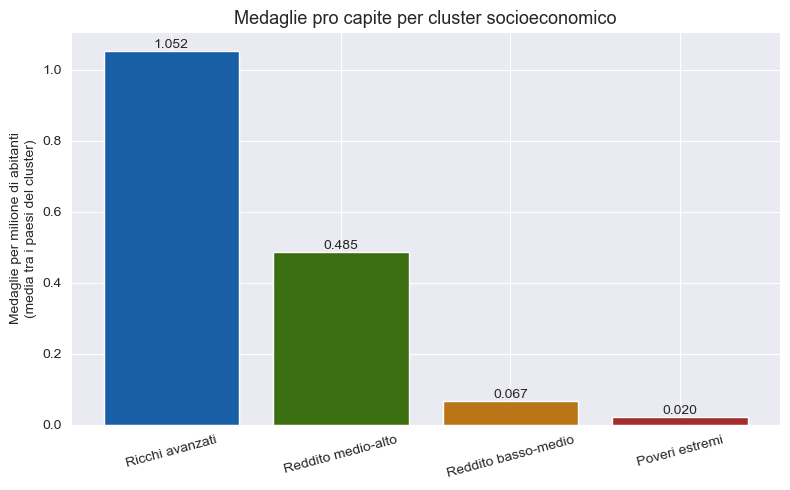

✓ Salvato: medaglie_pro_capite_cluster.png


In [17]:
# %% [N4] MEDAGLIE PRO CAPITE PER CLUSTER — CONFRONTO GENERALE
# -----------------------------------------------------------------------------
cluster_pc_summary = (
    country_year.groupby('cluster_label')['medals_per_million']
    .mean()
    .reindex(cluster_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors_list = [colors_cluster[c] for c in cluster_pc_summary.index]
ax.bar(cluster_pc_summary.index, cluster_pc_summary.values, color=colors_list)
ax.set_ylabel('Medaglie per milione di abitanti\n(media tra i paesi del cluster)')
ax.set_title('Medaglie pro capite per cluster socioeconomico', fontsize=13)
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(cluster_pc_summary.values):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('medaglie_pro_capite_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: medaglie_pro_capite_cluster.png")

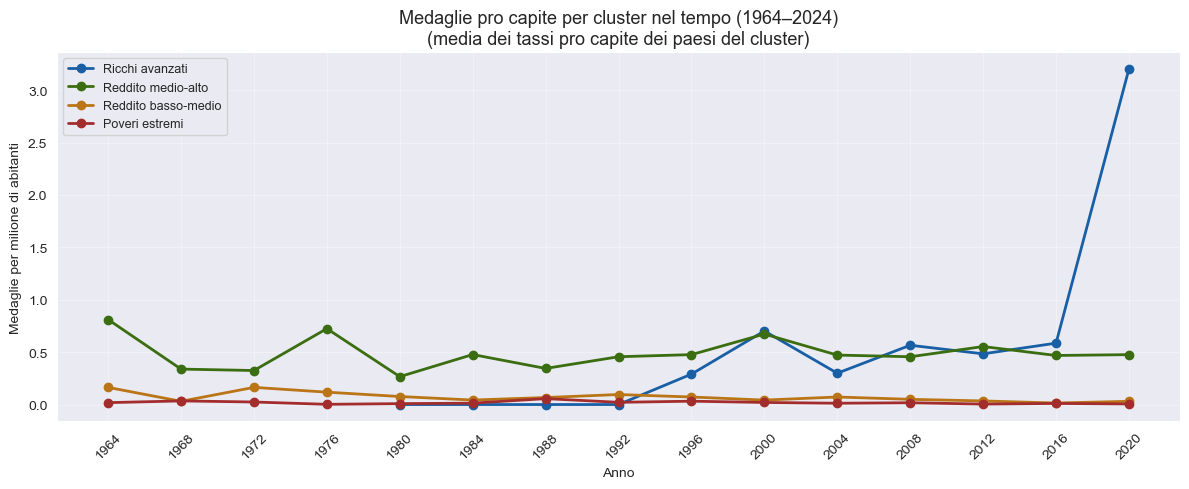

✓ Salvato: evoluzione_cluster_tempo_pro_capite.png


In [18]:
# %% [N5] EVOLUZIONE TEMPORALE PRO CAPITE
# -----------------------------------------------------------------------------
# Versione pro capite del grafico "Quota % di medaglie per cluster nel tempo":
# invece della quota % sul totale dell'edizione, mostra il tasso medio di
# medaglie per milione di abitanti, edizione per edizione.

time_cluster_pc = (
    country_year[country_year['year'] >= 1964]
    .groupby(['year', 'cluster_label'])['medals_per_million']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
for col in [c for c in cluster_order if c in time_cluster_pc.columns]:
    ax.plot(
        time_cluster_pc.index, time_cluster_pc[col],
        marker='o', linewidth=2, label=col, color=colors_cluster.get(col, 'gray')
    )

ax.set_title(
    'Medaglie pro capite per cluster nel tempo (1964–2024)\n'
    '(media dei tassi pro capite dei paesi del cluster)', fontsize=13
)
ax.set_xlabel('Anno')
ax.set_ylabel('Medaglie per milione di abitanti')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(time_cluster_pc.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('evoluzione_cluster_tempo_pro_capite.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: evoluzione_cluster_tempo_pro_capite.png")

In [19]:
# %% [N6] SPORT PRO CAPITE PER CLUSTER (versione normalizzata dell'heatmap [7])
# -----------------------------------------------------------------------------
# Stessa logica applicata sport per sport: per ogni paese-edizione calcoliamo
# quante medaglie/milione ha vinto in quello sport (zero-fill esplicito per
# i paesi che non hanno vinto nulla in quello sport), poi mediamo tra i
# paesi del cluster. Confrontabile direttamente con 'pivot_pct' (versione
# non normalizzata per popolazione).

roster_small = roster[['noc_ioc', 'year', 'cluster_label', 'population']].drop_duplicates()

# Griglia completa paese-edizione x sport (zero-fill esplicito)
sport_grid = roster_small.assign(key=1).merge(
    pd.DataFrame({'Sport': top_sports, 'key': 1}), on='key'
).drop(columns='key')

country_year_sport_medals = (
    event_medals[event_medals['Sport'].isin(top_sports)]
    .groupby(['Year', 'NOC', 'Sport'])['count']
    .sum()
    .reset_index(name='medals')
)

sport_grid = sport_grid.merge(
    country_year_sport_medals,
    left_on=['year', 'noc_ioc', 'Sport'], right_on=['Year', 'NOC', 'Sport'],
    how='left'
)
sport_grid['medals'] = sport_grid['medals'].fillna(0)
sport_grid['medals_per_million'] = sport_grid['medals'] / (sport_grid['population'] / 1e6)

print(f"Righe griglia paese-edizione x sport: {len(sport_grid):,}")

Righe griglia paese-edizione x sport: 78,450


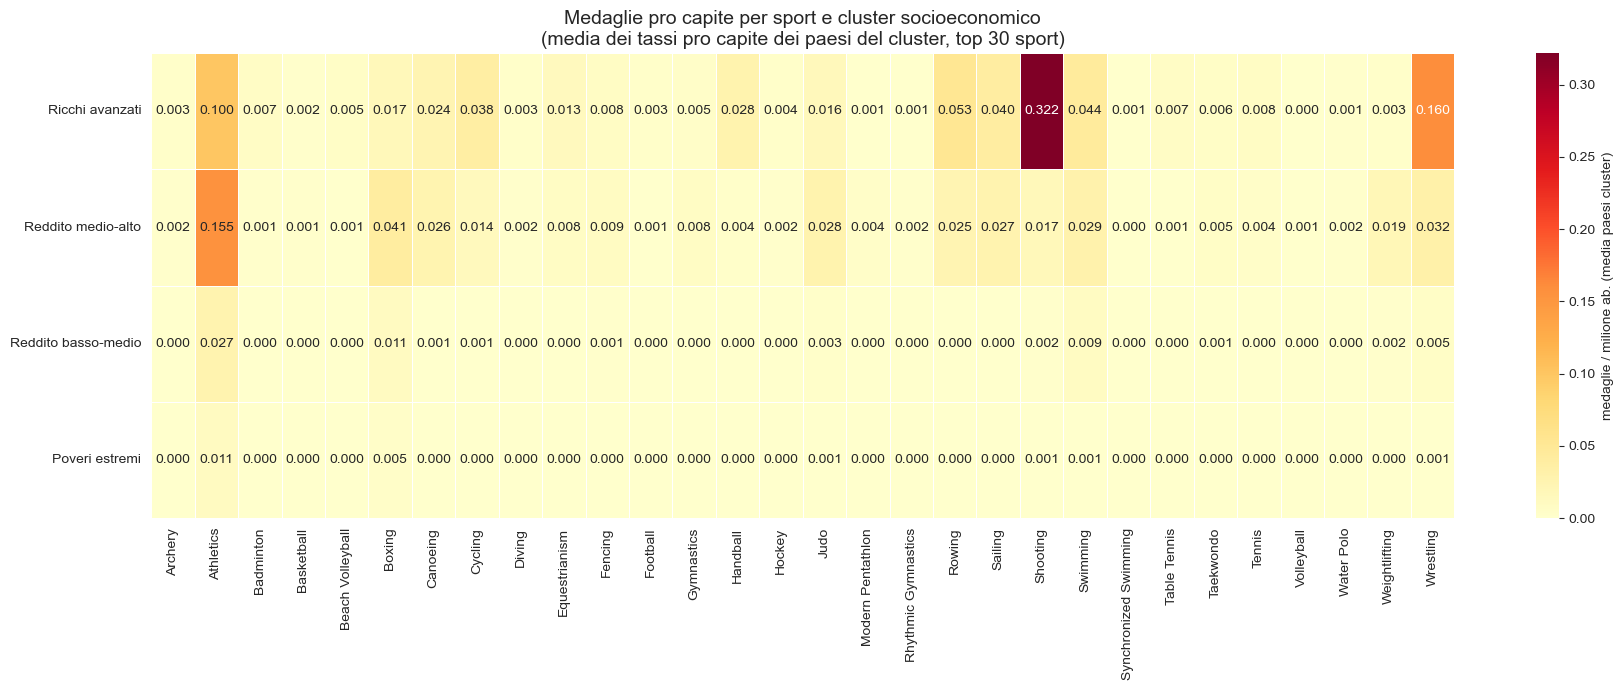

✓ Salvato: heatmap_sport_cluster_pro_capite.png


In [20]:
pivot_pc = (
    sport_grid.groupby(['cluster_label', 'Sport'])['medals_per_million']
    .mean()
    .unstack(fill_value=0)
    .reindex(cluster_order)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    pivot_pc,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'medaglie / milione ab. (media paesi cluster)'}
)
ax.set_title(
    'Medaglie pro capite per sport e cluster socioeconomico\n'
    '(media dei tassi pro capite dei paesi del cluster, top 30 sport)',
    fontsize=14
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_sport_cluster_pro_capite.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_sport_cluster_pro_capite.png")

In [21]:
# %% [N7] NOTA METODOLOGICA — DA INCLUDERE NELLA TESI
# -----------------------------------------------------------------------------
print("""
============================================================
NOTA METODOLOGICA — NORMALIZZAZIONE PER POPOLAZIONE
============================================================

Le metriche pro capite di questa sezione sono calcolate come media dei
tassi (medaglie / milione di abitanti) a livello di singolo paese-edizione,
non come rapporto tra il totale delle medaglie del cluster e la somma
delle popolazioni del cluster.

Motivazione: il rapporto aggregato è dominato dal paese più popoloso del
cluster; la media dei tassi individuali dà pari peso a ciascun paese e
include esplicitamente le edizioni con zero medaglie, evitando un bias
verso l'alto che si avrebbe mediando solo tra i paesi medagliati.

Limite da segnalare: la media semplice tratta un paese di pochi milioni
di abitanti allo stesso modo di uno di oltre un miliardo. È una scelta
consapevole (si vuole rispondere a "come si comporta in media un paese
di questo profilo economico", non "quante medaglie per abitante produce
il cluster nel suo complesso") e va dichiarata esplicitamente in tesi.
""")


NOTA METODOLOGICA — NORMALIZZAZIONE PER POPOLAZIONE

Le metriche pro capite di questa sezione sono calcolate come media dei
tassi (medaglie / milione di abitanti) a livello di singolo paese-edizione,
non come rapporto tra il totale delle medaglie del cluster e la somma
delle popolazioni del cluster.

Motivazione: il rapporto aggregato è dominato dal paese più popoloso del
cluster; la media dei tassi individuali dà pari peso a ciascun paese e
include esplicitamente le edizioni con zero medaglie, evitando un bias
verso l'alto che si avrebbe mediando solo tra i paesi medagliati.

Limite da segnalare: la media semplice tratta un paese di pochi milioni
di abitanti allo stesso modo di uno di oltre un miliardo. È una scelta
consapevole (si vuole rispondere a "come si comporta in media un paese
di questo profilo economico", non "quante medaglie per abitante produce
il cluster nel suo complesso") e va dichiarata esplicitamente in tesi.



In [22]:
# %% [6] TOP SPORT PER CLUSTER
# -----------------------------------------------------------------------------
print("=== TOP 10 SPORT PER CLUSTER ===\n")
for label in ['Ricchi avanzati', 'Reddito medio-alto', 'Reddito basso-medio', 'Poveri estremi']:
    subset = event_medals[event_medals['cluster_label'] == label]
    if len(subset) == 0:
        continue
    top = (
        subset.groupby('Sport')['count'].sum()
        .sort_values(ascending=False)
        .head(10)
    )
    total = top.sum()
    print(f"--- {label} ---")
    for sport, n in top.items():
        print(f"  {sport:<25} {n:>4}  ({n/total*100:.1f}%)")
    print()

=== TOP 10 SPORT PER CLUSTER ===

--- Ricchi avanzati ---
  Swimming                   363  (24.0%)
  Athletics                  287  (19.0%)
  Cycling                    143  (9.5%)
  Judo                       142  (9.4%)
  Rowing                     132  (8.7%)
  Sailing                    107  (7.1%)
  Canoeing                    88  (5.8%)
  Wrestling                   88  (5.8%)
  Shooting                    84  (5.6%)
  Gymnastics                  76  (5.0%)

--- Reddito medio-alto ---
  Athletics                  937  (21.5%)
  Swimming                   754  (17.3%)
  Wrestling                  486  (11.1%)
  Boxing                     373  (8.5%)
  Judo                       351  (8.0%)
  Canoeing                   321  (7.4%)
  Rowing                     296  (6.8%)
  Shooting                   291  (6.7%)
  Gymnastics                 278  (6.4%)
  Weightlifting              277  (6.3%)

--- Reddito basso-medio ---
  Athletics                  154  (25.5%)
  Boxing          

In [23]:
# %% [7] HEATMAP — SPORT × CLUSTER
# -----------------------------------------------------------------------------
# Calcoliamo la quota (%) di ogni sport sul totale di medaglie del cluster
# Questo normalizza le differenze di dimensione tra cluster

# Top 20 sport per numero totale di medaglie
top_sports = (
    event_medals.groupby('Sport')['count'].sum()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)

pivot = (
    event_medals[event_medals['Sport'].isin(top_sports)]
    .groupby(['cluster_label', 'Sport'])['count']
    .sum()
    .unstack(fill_value=0)
)

In [24]:
# Normalizziamo per riga (% sul totale del cluster)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Ordine cluster dal più ricco al più povero
cluster_order = ['Ricchi avanzati', 'Reddito medio-alto', 'Reddito basso-medio', 'Poveri estremi']
pivot_pct = pivot_pct.reindex([c for c in cluster_order if c in pivot_pct.index])


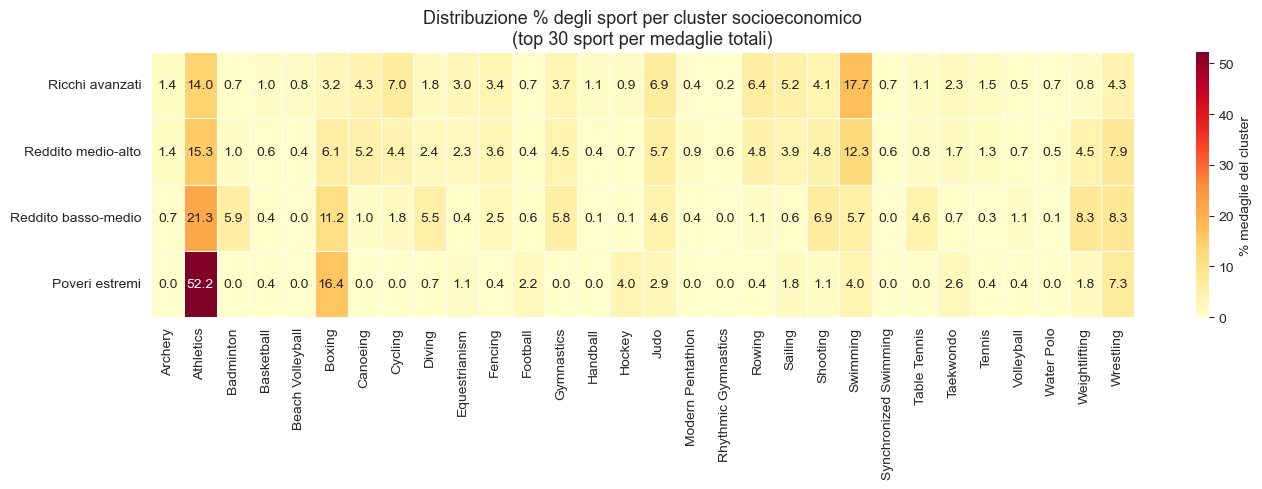

✓ Salvato: heatmap_sport_cluster.png


In [25]:

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_pct,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% medaglie del cluster'}
)
ax.set_title('Distribuzione % degli sport per cluster socioeconomico\n(top 30 sport per medaglie totali)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_sport_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_sport_cluster.png")


In [26]:
# %% [8] SPORT DISTINTIVI PER CLUSTER (indice di specializzazione)
# -----------------------------------------------------------------------------
# Calcoliamo quanto uno sport è sovra/sotto-rappresentato in un cluster
# rispetto alla media globale: specialization = (% cluster) / (% globale)
# Valori > 1 = sport più frequente nel cluster rispetto alla media

global_pct = (
    event_medals[event_medals['Sport'].isin(top_sports)]
    .groupby('Sport')['count'].sum()
)
global_pct = global_pct / global_pct.sum() * 100

specialization = pivot_pct.div(global_pct, axis=1)

print("=== INDICE DI SPECIALIZZAZIONE (>1 = sovra-rappresentato) ===\n")
for label in [c for c in cluster_order if c in specialization.index]:
    top3 = specialization.loc[label].sort_values(ascending=False).head(5)
    bot3 = specialization.loc[label].sort_values(ascending=True).head(3)
    print(f"--- {label} ---")
    print("  Sport distintivi:")
    for sport, idx in top3.items():
        print(f"    {sport:<25} indice={idx:.2f}x")
    print("  Sport meno presenti:")
    for sport, idx in bot3.items():
        print(f"    {sport:<25} indice={idx:.2f}x")
    print()


=== INDICE DI SPECIALIZZAZIONE (>1 = sovra-rappresentato) ===

--- Ricchi avanzati ---
  Sport distintivi:
    Handball                  indice=2.02x
    Beach Volleyball          indice=1.86x
    Basketball                indice=1.57x
    Cycling                   indice=1.50x
    Swimming                  indice=1.39x
  Sport meno presenti:
    Weightlifting             indice=0.21x
    Rhythmic Gymnastics       indice=0.42x
    Boxing                    indice=0.52x

--- Reddito medio-alto ---
  Sport distintivi:
    Rhythmic Gymnastics       indice=1.36x
    Modern Pentathlon         indice=1.24x
    Canoeing                  indice=1.16x
    Weightlifting             indice=1.16x
    Wrestling                 indice=1.11x
  Sport meno presenti:
    Table Tennis              indice=0.71x
    Badminton                 indice=0.76x
    Football                  indice=0.76x

--- Reddito basso-medio ---
  Sport distintivi:
    Badminton                 indice=4.62x
    Table Tennis   

In [27]:
# %% [9] TEST CHI-QUADRO — LA DISTRIBUZIONE DEGLI SPORT DIPENDE DAL CLUSTER?
# -----------------------------------------------------------------------------
# H0: la distribuzione degli sport è indipendente dal cluster
# H1: esiste una relazione tra cluster socioeconomico e sport in cui si vince

contingency = (
    event_medals[event_medals['Sport'].isin(top_sports)]
    .groupby(['cluster_label', 'Sport'])['count']
    .sum()
    .unstack(fill_value=0)
)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("=== TEST CHI-QUADRO ===")
print(f"Chi²  = {chi2:.2f}")
print(f"p-value = {p_value:.2e}")
print(f"Gradi di libertà = {dof}")
print()
if p_value < 0.05:
    print("✓ Risultato: p < 0.05 — rifiutiamo H0.")
    print("  La distribuzione degli sport è significativamente diversa tra cluster.")
    print("  Esiste una relazione tra condizione socioeconomica e sport olimpici vinti.")
else:
    print("✗ Risultato: p >= 0.05 — non rifiutiamo H0.")
    print("  Non c'è evidenza sufficiente di una relazione.")

=== TEST CHI-QUADRO ===
Chi²  = 1190.94
p-value = 2.46e-193
Gradi di libertà = 87

✓ Risultato: p < 0.05 — rifiutiamo H0.
  La distribuzione degli sport è significativamente diversa tra cluster.
  Esiste una relazione tra condizione socioeconomica e sport olimpici vinti.


In [28]:
# %% [10] EVOLUZIONE TEMPORALE — I CLUSTER CAMBIANO NEL TEMPO?
# -----------------------------------------------------------------------------
# Vediamo se la quota di medaglie di ogni cluster è cambiata nel corso delle edizioni

time_cluster = (
    event_medals[event_medals['Year'] >= 1964]
    .groupby(['Year', 'cluster_label'])['count']
    .sum()
    .unstack(fill_value=0)
)

In [29]:
# Normalizziamo per riga (% per anno)
time_cluster_pct = time_cluster.div(time_cluster.sum(axis=1), axis=0) * 100

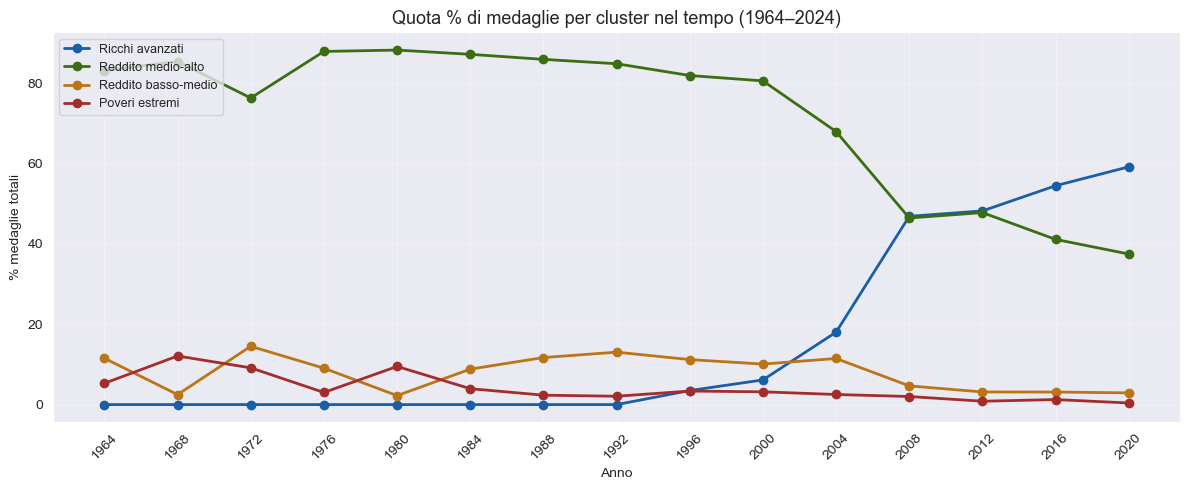

✓ Salvato: evoluzione_cluster_tempo.png


In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'Ricchi avanzati': '#185FA5', 'Reddito medio-alto': '#3B6D11',
          'Reddito basso-medio': '#BA7517', 'Poveri estremi': '#A32D2D'}

for col in [c for c in cluster_order if c in time_cluster_pct.columns]:
    ax.plot(
        time_cluster_pct.index,
        time_cluster_pct[col],
        marker='o', linewidth=2,
        label=col, color=colors.get(col, 'gray')
    )

ax.set_title('Quota % di medaglie per cluster nel tempo (1964–2024)', fontsize=13)
ax.set_xlabel('Anno')
ax.set_ylabel('% medaglie totali')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(time_cluster_pct.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('evoluzione_cluster_tempo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: evoluzione_cluster_tempo.png")


In [31]:
# %% [11] SALVATAGGIO DATASET FINALE
# -----------------------------------------------------------------------------
df_clean.to_csv('olympics_sport_cluster.csv', index=False)
print(f"\n✓ Salvato: olympics_sport_cluster.csv")
print(f"   {len(df_clean):,} medaglie con sport, anno, NOC e cluster socioeconomico")
print("\nColonne disponibili:")
print(df_clean.columns.tolist())


✓ Salvato: olympics_sport_cluster.csv
   20,119 medaglie con sport, anno, NOC e cluster socioeconomico

Colonne disponibili:
['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'noc_ioc', 'year', 'cluster_label', 'cluster']


## Mobilità tra cluster nel tempo

Tutta l'analisi sport di questo notebook usa ormai il **cluster dinamico**
(`cluster_label` costruito da `mobility_lookup_dyn`, calcolato più sopra nella
sezione "ANALISI SPORT PER CLUSTER SOCIOECONOMICO" — cella `[3bis]`): il
cluster socioeconomico REALE del paese nell'anno in cui ha vinto la medaglia,
non il suo cluster più recente/attuale.

Qui riusiamo la tabella `mobility` già calcolata (stesso modello di
clustering multivariato: K-means su PIL pro capite, aspettativa di vita,
urbanizzazione, mortalità infantile e iscrizione scolastica primaria) per
un'analisi complementare: non più "a che cluster appartiene ogni medaglia",
ma "quali paesi hanno attraversato transizioni economiche importanti nel
periodo coperto dai dati" (es. Corea del Sud, Cina), passando da una fascia
di reddito all'altra. Se il loro medal-count è cambiato in modo coerente con
quella transizione, abbiamo un argomento più vicino alla causalità rispetto
alla sola correlazione trasversale PIL-medaglie tra paesi diversi — perché
qui confrontiamo lo **stesso paese** con se stesso nel tempo, tenendo
relativamente costanti molti fattori confondenti (cultura sportiva, storia,
dimensione).

In [32]:
# %% [10ter] PAESI CHE HANNO CAMBIATO CLUSTER NEL PERIODO 1964-2024
# -----------------------------------------------------------------------------
cluster_rank = {
    'Poveri estremi': 0,
    'Reddito basso-medio': 1,
    'Reddito medio-alto': 2,
    'Ricchi avanzati': 3,
}
mobility['cluster_rank'] = mobility['cluster_dynamic'].map(cluster_rank)

transitions = (
    mobility.sort_values('year')
    .groupby('noc_ioc')
    .agg(
        country=('country', 'first'),
        cluster_iniziale=('cluster_dynamic', 'first'),
        cluster_finale=('cluster_dynamic', 'last'),
        rank_iniziale=('cluster_rank', 'first'),
        rank_finale=('cluster_rank', 'last'),
        anno_iniziale=('year', 'first'),
        anno_finale=('year', 'last'),
        n_osservazioni=('year', 'nunique'),
    )
    .reset_index()
)

transitions['salto_cluster'] = transitions['rank_finale'] - transitions['rank_iniziale']

# Teniamo solo i paesi che hanno effettivamente cambiato fascia
# e con una storia sufficientemente lunga da essere informativa
movers = (
    transitions[
        (transitions['salto_cluster'] != 0) &
        (transitions['n_osservazioni'] >= 4)
    ]
    .sort_values('salto_cluster', ascending=False)
)

print(f"Paesi che hanno cambiato fascia di reddito (1964-2024): {len(movers)}")
print()
print("=== TOP 'PROMOSSI' (salita di fascia più marcata) ===")
print(movers.head(10)[['country', 'cluster_iniziale', 'cluster_finale',
                        'anno_iniziale', 'anno_finale', 'salto_cluster']].to_string(index=False))
print()
print("=== TOP 'RETROCESSI' (discesa di fascia più marcata) ===")
print(movers.tail(10)[['country', 'cluster_iniziale', 'cluster_finale',
                        'anno_iniziale', 'anno_finale', 'salto_cluster']].to_string(index=False))

Paesi che hanno cambiato fascia di reddito (1964-2024): 148

=== TOP 'PROMOSSI' (salita di fascia più marcata) ===
             country    cluster_iniziale     cluster_finale  anno_iniziale  anno_finale  salto_cluster
   Republic of Korea      Poveri estremi    Ricchi avanzati           1964         2020              3
United Arab Emirates      Poveri estremi    Ricchi avanzati           1972         2020              3
              Kuwait      Poveri estremi    Ricchi avanzati           1964         2020              3
             Algeria      Poveri estremi Reddito medio-alto           1964         2020              2
              Brazil      Poveri estremi Reddito medio-alto           1964         2020              2
   Brunei Darussalam Reddito basso-medio    Ricchi avanzati           1968         2020              2
              Bhutan      Poveri estremi Reddito medio-alto           1972         2020              2
           Indonesia      Poveri estremi Reddito medio-alto  

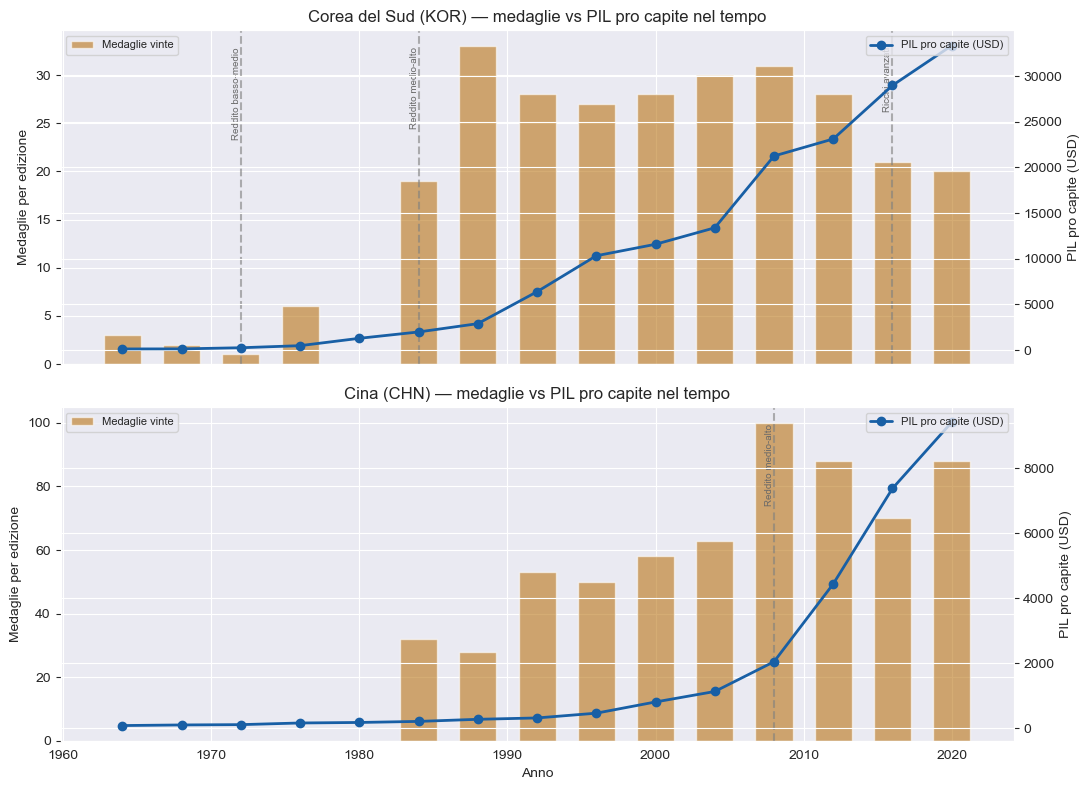

✓ Salvato: mobilita_cluster_case_studies.png


In [33]:
# %% [10quater] CASE STUDY — COREA DEL SUD E CINA
# -----------------------------------------------------------------------------
# Corea del Sud e Cina sono tra gli esempi più citati in letteratura di rapida
# transizione economica nel dopoguerra. Sovrapponiamo la loro traiettoria di
# PIL pro capite (con i punti di passaggio da un cluster all'altro) al numero
# di medaglie vinte edizione per edizione.

CASE_STUDIES = {
    'KOR': 'Corea del Sud',
    'CHN': 'Cina',
}

medals_by_year = (
    event_medals.groupby(['Year', 'NOC'])['count']
    .sum()
    .reset_index(name='medals')
)

fig, axes = plt.subplots(len(CASE_STUDIES), 1, figsize=(11, 4 * len(CASE_STUDIES)), sharex=True)

for ax, (noc, label) in zip(axes, CASE_STUDIES.items()):
    traj = mobility[mobility['noc_ioc'] == noc].sort_values('year')
    m = medals_by_year[medals_by_year['NOC'] == noc].sort_values('Year')

    ax2 = ax.twinx()
    ax.bar(m['Year'], m['medals'], color='#BA7517', alpha=0.6, width=2.5, label='Medaglie vinte')
    ax2.plot(traj['year'], traj['gdp_per_capita'], color='#185FA5', marker='o',
             linewidth=2, label='PIL pro capite (USD)')

    # Evidenziamo gli anni in cui il paese passa da un cluster all'altro
    traj_shift = traj[traj['cluster_dynamic'] != traj['cluster_dynamic'].shift(1)]
    for _, row in traj_shift.iloc[1:].iterrows():
        ax.axvline(row['year'], color='gray', linestyle='--', alpha=0.6)
        ax.text(row['year'], ax.get_ylim()[1] * 0.95, row['cluster_dynamic'],
                rotation=90, fontsize=7, va='top', ha='right', color='dimgray')

    ax.set_title(f'{label} ({noc}) — medaglie vs PIL pro capite nel tempo', fontsize=12)
    ax.set_ylabel('Medaglie per edizione')
    ax2.set_ylabel('PIL pro capite (USD)')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Anno')
plt.tight_layout()
plt.savefig('mobilita_cluster_case_studies.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: mobilita_cluster_case_studies.png")

In [34]:
# %% [10quinquies] MEDAL-COUNT PRIMA E DOPO IL CAMBIO DI CLUSTER (TUTTI I PAESI)
# -----------------------------------------------------------------------------
# Generalizziamo il case study a tutti i paesi individuati in 'movers': per
# ciascuno confrontiamo le medaglie pro capite medie PRIMA e DOPO l'anno di
# transizione. Se la relazione PIL-medaglie osservata in sezione trasversale
# riflette un meccanismo reale (e non solo il fatto che paesi diversi sono
# diversi), ci aspettiamo che lo stesso paese vinca più medaglie pro capite
# DOPO essere salito di fascia.

before_after = []
for _, row in movers.iterrows():
    noc = row['noc_ioc']
    country_traj = mobility[mobility['noc_ioc'] == noc].sort_values('year')
    # Anno di transizione: primo anno in cui il paese esce dalla fascia iniziale
    shift_year = country_traj.loc[
        country_traj['cluster_dynamic'] != row['cluster_iniziale'], 'year'
    ]
    if shift_year.empty:
        continue
    transition_year = shift_year.iloc[0]

    cy = country_year[country_year['noc_ioc'] == noc]
    pre = cy[cy['year'] < transition_year]['medals_per_million'].mean()
    post = cy[cy['year'] >= transition_year]['medals_per_million'].mean()

    if pd.notna(pre) and pd.notna(post):
        before_after.append({
            'country': row['country'], 'noc': noc,
            'cluster_iniziale': row['cluster_iniziale'],
            'cluster_finale': row['cluster_finale'],
            'anno_transizione': transition_year,
            'medaglie_pc_prima': pre,
            'medaglie_pc_dopo': post,
            'variazione_pct': (post - pre) / pre * 100 if pre > 0 else np.nan,
        })

before_after_df = pd.DataFrame(before_after).sort_values('variazione_pct', ascending=False)
print(before_after_df.round(3).to_string(index=False))

n_up = (before_after_df['variazione_pct'] > 0).sum()
print(f"\n{n_up}/{len(before_after_df)} paesi saliti di fascia hanno aumentato"
      f" le medaglie pro capite dopo la transizione.")

                          country noc    cluster_iniziale      cluster_finale  anno_transizione  medaglie_pc_prima  medaglie_pc_dopo  variazione_pct
                            Egypt EGY      Poveri estremi  Reddito medio-alto              2004              0.002             0.038        1637.160
                        Hong Kong HKG  Reddito medio-alto     Ricchi avanzati              2000              0.019             0.183         885.604
                         Thailand THA      Poveri estremi  Reddito medio-alto              1984              0.005             0.049         858.872
                       Azerbaijan AZE      Poveri estremi  Reddito medio-alto              2004              0.171             1.033         503.225
                       Kyrgyzstan KGZ Reddito basso-medio  Reddito medio-alto              2020              0.085             0.470         451.682
                Republic of Korea KOR      Poveri estremi     Ricchi avanzati              1972           

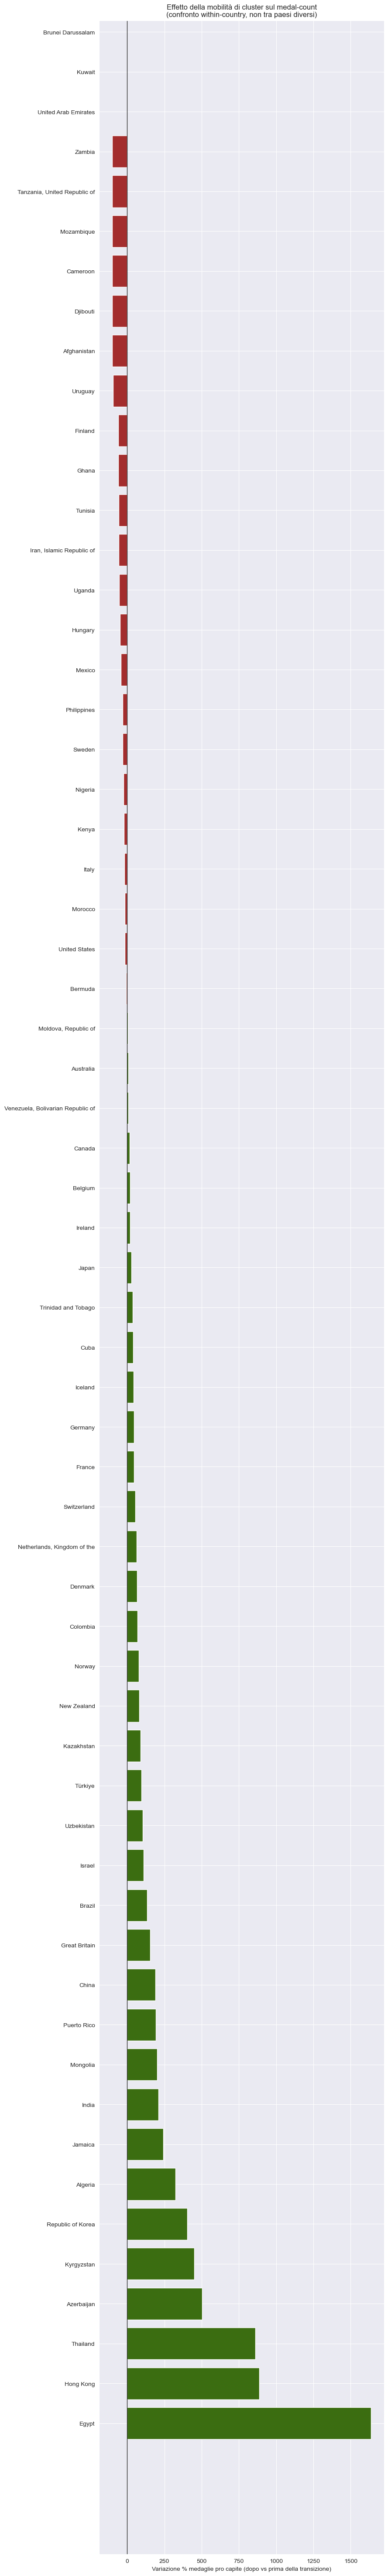

✓ Salvato: mobilita_cluster_variazione_medaglie.png


In [35]:
# %% [10sexies] VISUALIZZAZIONE — VARIAZIONE MEDAGLIE PRO CAPITE PRIMA/DOPO
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(before_after_df))))
colors_ba = ['#3B6D11' if v >= 0 else '#A32D2D' for v in before_after_df['variazione_pct']]
ax.barh(before_after_df['country'], before_after_df['variazione_pct'], color=colors_ba)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Variazione % medaglie pro capite (dopo vs prima della transizione)')
ax.set_title(
    'Effetto della mobilità di cluster sul medal-count\n'
    '(confronto within-country, non tra paesi diversi)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('mobilita_cluster_variazione_medaglie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: mobilita_cluster_variazione_medaglie.png")

### Nota interpretativa

Il confronto *prima/dopo* a livello di singolo paese è un argomento più vicino alla causalità rispetto alla sola correlazione trasversale (PIL più alto → più medaglie, confrontando paesi diversi tra loro): qui osserviamo lo stesso paese nel tempo, quindi molti fattori confondenti che cambiano poco nel breve periodo (cultura sportiva, storia olimpica, dimensione del paese) restano relativamente costanti.

Limiti da segnalare comunque nella tesi:
- il numero di paesi che cambia effettivamente fascia in 60 anni è piccolo, quindi la stima prima/dopo ha varianza alta — vanno controllati i paesi con poche osservazioni (`n_osservazioni`);
- la crescita del medal-count può riflettere anche investimenti statali mirati nello sport, non solo la crescita economica generale (es. Cina, Corea del Sud, ex Unione Sovietica): la relazione resta comunque correlazionale, non un esperimento randomizzato;
- l'anno di transizione è definito come il primo anno in cui il paese esce dalla fascia iniziale — una soglia potenzialmente sensibile al rumore statistico del PIL in un singolo anno; andrebbe verificata la robustezza usando ad esempio una media mobile del cluster su più edizioni.

## CAMBIO DI PROSPETTIVA

In [36]:
# =============================================================================
# CELLE AGGIUNTIVE — PROSPETTIVA "PER SPORT"
# Chi domina ogni disciplina olimpica?
# =============================================================================
# Da aggiungere in fondo ad analisi_sport_cluster.py
# Prerequisito: event_medals, pivot, cluster_order già definiti nelle celle precedenti
# =============================================================================


# %% [12] HEATMAP NORMALIZZATA PER SPORT
# -----------------------------------------------------------------------------
# Ogni colonna somma a 100%: mostra quale cluster domina ogni singolo sport.
# Complementare alla cella [7] dove ogni riga sommava a 100%.

In [37]:
pivot_pct_col = pivot.div(pivot.sum(axis=0), axis=1) * 100

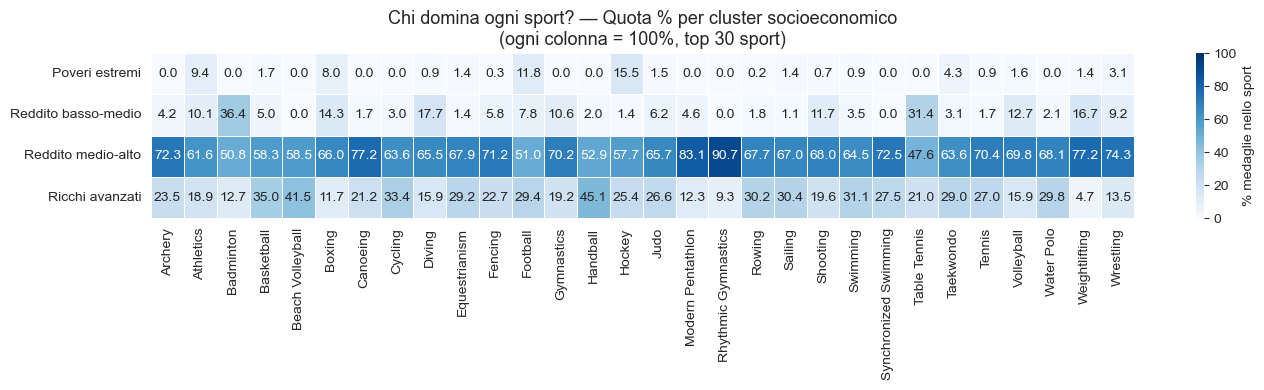

✓ Salvato: heatmap_chi_domina_sport.png


In [38]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot_pct_col,
    annot=True, fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': '% medaglie nello sport'}
)
ax.set_title(
    'Chi domina ogni sport? — Quota % per cluster socioeconomico\n'
    '(ogni colonna = 100%, top 30 sport)',
    fontsize=13
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_chi_domina_sport.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_chi_domina_sport.png")

In [39]:
# %% [13] SPORT PIÙ E MENO "DEMOCRATICI"
# -----------------------------------------------------------------------------
# Definiamo "democraticità" di uno sport come la quota di medaglie
# vinta dai cluster NON ricchi (medio-alto + basso-medio + poveri estremi).
# Più alto il valore, più lo sport è accessibile a paesi meno sviluppati.

non_rich_clusters = ['Reddito basso-medio', 'Poveri estremi']
non_rich_share = (
    pivot_pct_col
    .reindex([c for c in non_rich_clusters if c in pivot_pct_col.index])
    .sum(axis=0)
    .sort_values(ascending=False)
)

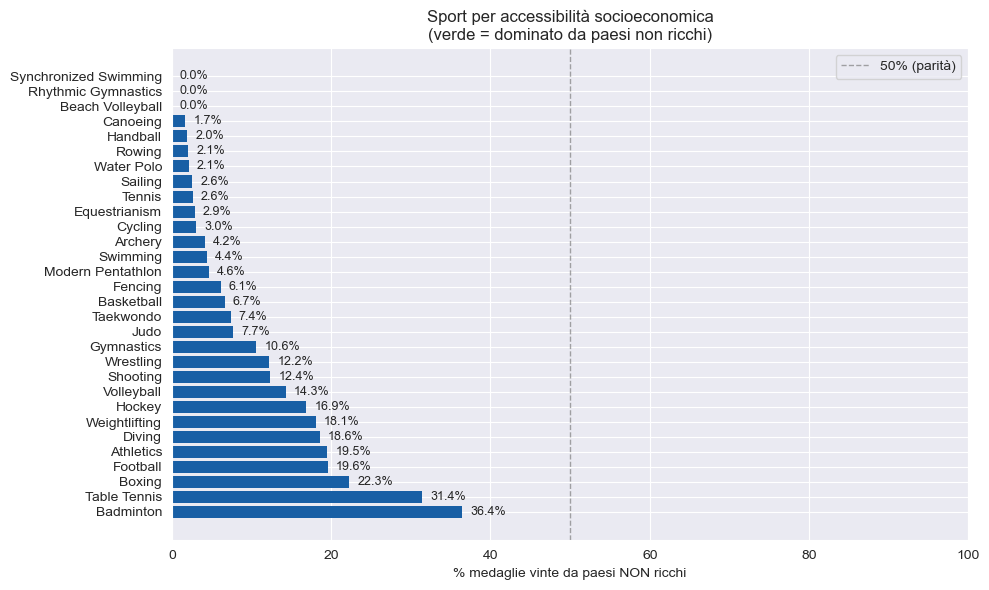

✓ Salvato: sport_accessibilita.png

=== SPORT PIÙ ACCESSIBILI (dominati da paesi non ricchi) ===
Series([], )

=== SPORT MENO ACCESSIBILI (dominati da paesi ricchi) ===
Sport
Synchronized Swimming     0.000000
Beach Volleyball          0.000000
Rhythmic Gymnastics       0.000000
Canoeing                  1.682692
Handball                  1.960784
Rowing                    2.059497
Water Polo                2.127660
Sailing                   2.556818
Tennis                    2.608696
Equestrianism             2.870813
Cycling                   3.037383
Archery                   4.201681
Swimming                  4.448246
Modern Pentathlon         4.615385
Fencing                   6.148867
Basketball                6.666667
Taekwondo                 7.407407
Judo                      7.677903
Gymnastics               10.606061
Wrestling                12.232416
Shooting                 12.383178
Volleyball               14.285714
Hockey                   16.901408
Weightlifting       

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3B6D11' if v >= 50 else '#185FA5' for v in non_rich_share.values]
bars = ax.barh(non_rich_share.index, non_rich_share.values, color=colors, edgecolor='none')

ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='50% (parità)')
ax.set_xlabel('% medaglie vinte da paesi NON ricchi')
ax.set_title('Sport per accessibilità socioeconomica\n(verde = dominato da paesi non ricchi)', fontsize=12)
ax.legend()
ax.set_xlim(0, 100)

for bar, val in zip(bars, non_rich_share.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('sport_accessibilita.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: sport_accessibilita.png")

print("\n=== SPORT PIÙ ACCESSIBILI (dominati da paesi non ricchi) ===")
print(non_rich_share[non_rich_share >= 50].to_string())
print("\n=== SPORT MENO ACCESSIBILI (dominati da paesi ricchi) ===")
print(non_rich_share[non_rich_share < 30].sort_values().to_string())

In [41]:
# %% [14] STACKED BAR — COMPOSIZIONE DI OGNI SPORT PER CLUSTER
# -----------------------------------------------------------------------------
# Una barra per sport, divisa per cluster: permette di leggere
# rapidamente la "firma socioeconomica" di ogni disciplina.

colors_cluster = {
    'Ricchi avanzati':      '#185FA5',
    'Reddito medio-alto':   '#3B6D11',
    'Reddito basso-medio':  '#BA7517',
    'Poveri estremi':       '#A32D2D',
}

In [42]:
# Ordiniamo gli sport per quota "ricchi avanzati" (dal più esclusivo al meno)
sport_order = pivot_pct_col.loc['Ricchi avanzati'].sort_values(ascending=True).index.tolist()
data_ordered = pivot_pct_col[sport_order]

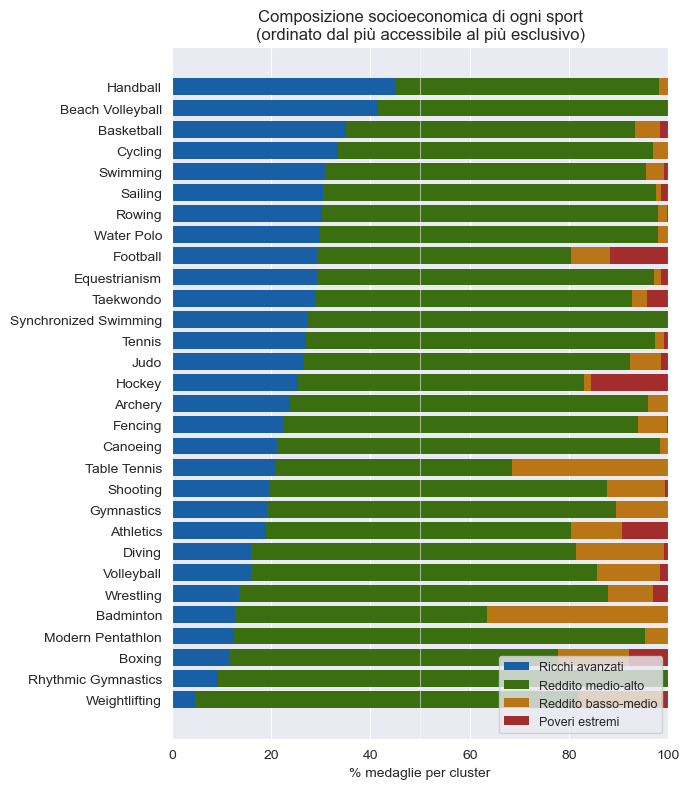

✓ Salvato: composizione_sport_cluster.png


In [43]:
fig, ax = plt.subplots(figsize=(7,8))
bottom = np.zeros(len(sport_order))

for label in [c for c in cluster_order if c in data_ordered.index]:
    values = data_ordered.loc[label].values
    ax.barh(
        sport_order, values, left=bottom,
        color=colors_cluster[label], label=label, edgecolor='none'
    )
    bottom += values

ax.set_xlabel('% medaglie per cluster')
ax.set_title(
    'Composizione socioeconomica di ogni sport\n'
    '(ordinato dal più accessibile al più esclusivo)',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 100)
ax.axvline(50, color='white', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('composizione_sport_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: composizione_sport_cluster.png")


## Salvataggio degli output aggiuntivi per i notebook successivi

In [44]:
# %% [S] SALVATAGGIO — tabelle di supporto per 04_Cluster_Statico.ipynb e 06_Grafici_Altair.ipynb
# -----------------------------------------------------------------------------
mobility[['noc_ioc', 'country', 'year', 'cluster_dynamic']].to_csv(
    'mobility_dynamic.csv', index=False
)
print("✓ Salvato: mobility_dynamic.csv")

cluster_pc_summary.to_frame(name='medals_per_million').to_csv(
    'cluster_pc_summary_dynamic.csv'
)
print("✓ Salvato: cluster_pc_summary_dynamic.csv")

✓ Salvato: mobility_dynamic.csv
✓ Salvato: cluster_pc_summary_dynamic.csv
